<div style="text-align: center; padding: 40px 20px; background: linear-gradient(135deg, #f5f7fa 0%, #c3cfe2 100%); border-radius: 15px;">
    <img src="../logo/CICESE.jpg" alt="CICESE" style="width: 200px; margin-bottom: 30px;">
    <h1 style="color: #003366; font-size: 36px; margin-bottom: 10px;">Predicción de Bicicletas Rentadas</h1>
    <h2 style="color: #005599; font-size: 24px; margin-bottom: 20px;">Regresión</h2>
    <hr style="border: 2px solid #003366; width: 50%;">
    <p style="color: #003366; font-size: 20px; margin-top: 20px;"><strong>Javier Ramirez</strong></p>
    <p style="color: #666; font-size: 16px;">CICESE · Reconocimiento de Patrones</p>
</div>

## 1. Objetivo

Construir un modelo de regresión que estime la cantidad de bicicletas rentadas por hora a partir de datos meteorológicos y temporales. La evaluación se realiza con validación temporal y la predicción final se entrega en formato `predicciones.csv`.

In [18]:
import os
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from datetime import datetime

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
np.random.seed(42)

In [19]:
OUTPUT_DIR = f"outputs/run_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Salida {OUTPUT_DIR}/")

Salida outputs/run_20260728_235006/


## 2. Carga de datos

Se cargan los archivos `Interno/train.csv` y `externo/test.csv`. Ambos se ordenan por timestamp y se preserva el orden original del conjunto de prueba para la submission.

In [20]:
train = pd.read_csv('Interno/train.csv', parse_dates=['timestamp'])
test = pd.read_csv('externo/test.csv', parse_dates=['timestamp'])

train['_original_order'] = np.arange(len(train))
test['_original_order'] = np.arange(len(test))

train = train.sort_values('timestamp').reset_index(drop=True)
test_sorted = test.sort_values('timestamp').reset_index(drop=True)

y = train['cnt'].copy().values

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")

Train: (15414, 11)
Test:  (2000, 10)


In [21]:
train.head()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season,_original_order
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0,0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0,1
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0,2
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0,3
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0,4


## 3. Análisis exploratorio (EDA)

Se analiza la serie temporal, distribución, estacionalidad, autocorrelación y relaciones con variables climáticas.

In [22]:
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import PowerTransformer

print('Estadísticas descriptivas de cnt')
print(f'  Media:   {y.mean():>8.1f}')
print(f'  Std:     {y.std():>8.1f}')
print(f'  Mín:     {y.min():>8.0f}')
print(f'  P25:     {np.percentile(y, 25):>8.0f}')
print(f'  P50:     {np.median(y):>8.0f}')
print(f'  P75:     {np.percentile(y, 75):>8.0f}')
print(f'  Máx:     {y.max():>8.0f}')
print(f'  Skew:    {stats.skew(y):>8.3f}')
print(f'  Kurt:    {stats.kurtosis(y):>8.3f}')

adf = adfuller(y)
print(f'\nEstacionariedad (ADF): p-valor={adf[1]:.2e}  {"estacionaria" if adf[1] < 0.05 else "no estacionaria"}')

pt = PowerTransformer(method='yeo-johnson')
lam = pt.fit(y.reshape(-1, 1)).lambdas_[0]
print(f'\nPowerTransformer lambda: {lam:.4f}')

Estadísticas descriptivas de cnt
  Media:     1163.4
  Std:       1099.3
  Mín:            0
  P25:          263
  P50:          856
  P75:         1715
  Máx:         7860
  Skew:       1.299
  Kurt:       1.443

Estacionariedad (ADF): p-valor=2.13e-15  estacionaria

PowerTransformer lambda: 0.2578


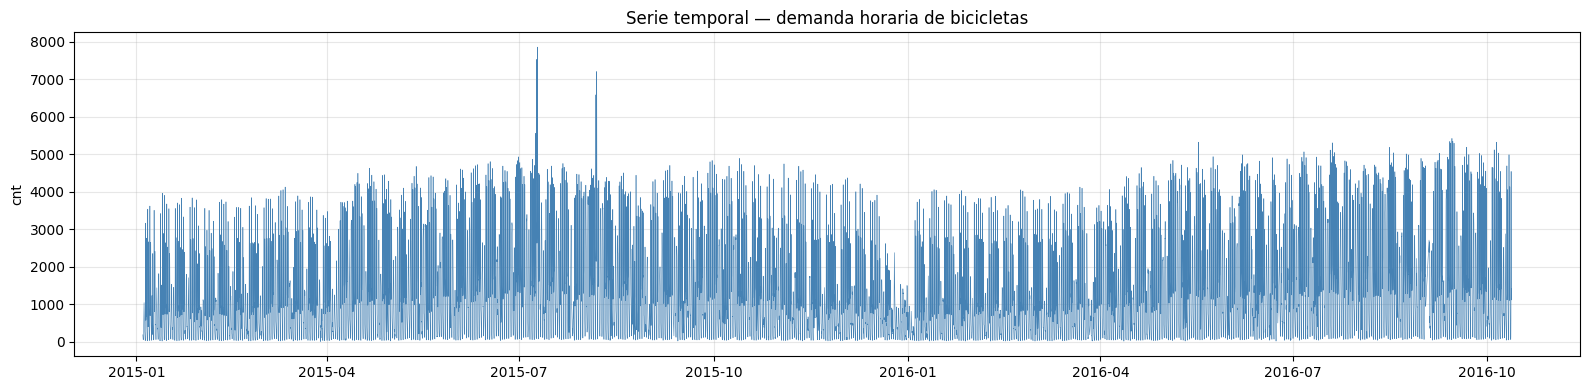

In [23]:
# Serie temporal completa
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(train['timestamp'], y, linewidth=0.4, color='steelblue')
ax.set_title('Serie temporal — demanda horaria de bicicletas')
ax.set_ylabel('cnt'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, '01_serie_temporal.png'), dpi=150, bbox_inches='tight')

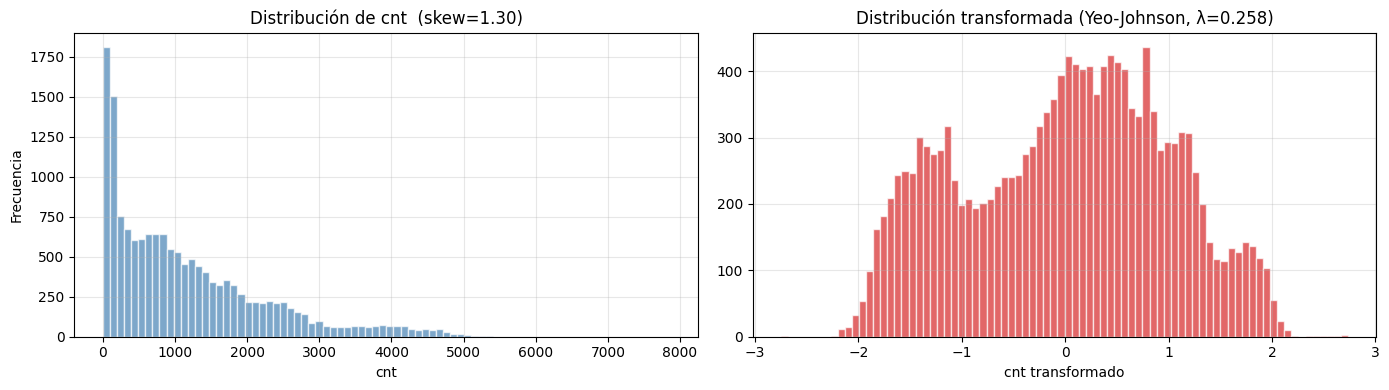

In [24]:
# Distribución
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.hist(y, bins=80, color='steelblue', edgecolor='white', alpha=0.7)
ax1.set_title(f'Distribución de cnt  (skew={stats.skew(y):.2f})')
ax1.set_xlabel('cnt'); ax1.set_ylabel('Frecuencia')

y_pt = PowerTransformer(method='yeo-johnson').fit_transform(y.reshape(-1, 1)).ravel()
ax2.hist(y_pt, bins=80, color='#d62728', edgecolor='white', alpha=0.7)
ax2.set_title(f'Distribución transformada (Yeo-Johnson, λ={lam:.3f})')
ax2.set_xlabel('cnt transformado')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'distribucion_cnt.png'), dpi=150, bbox_inches='tight')

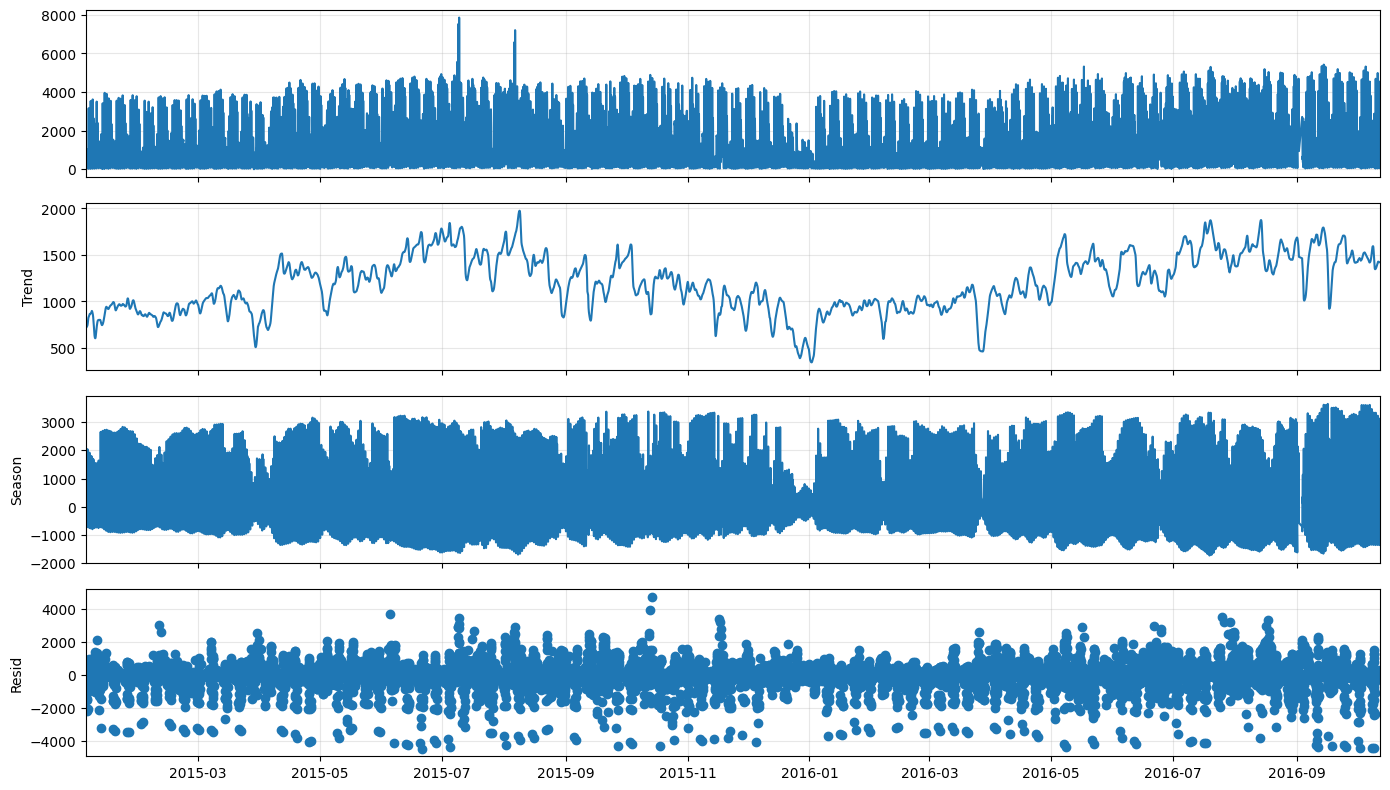

In [25]:
# STL decomposition
stl = STL(pd.Series(y, index=train['timestamp']), period=24, robust=True)
res = stl.fit()
fig = res.plot()
fig.set_size_inches(14, 8)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, '02_stl.png'), dpi=150, bbox_inches='tight')

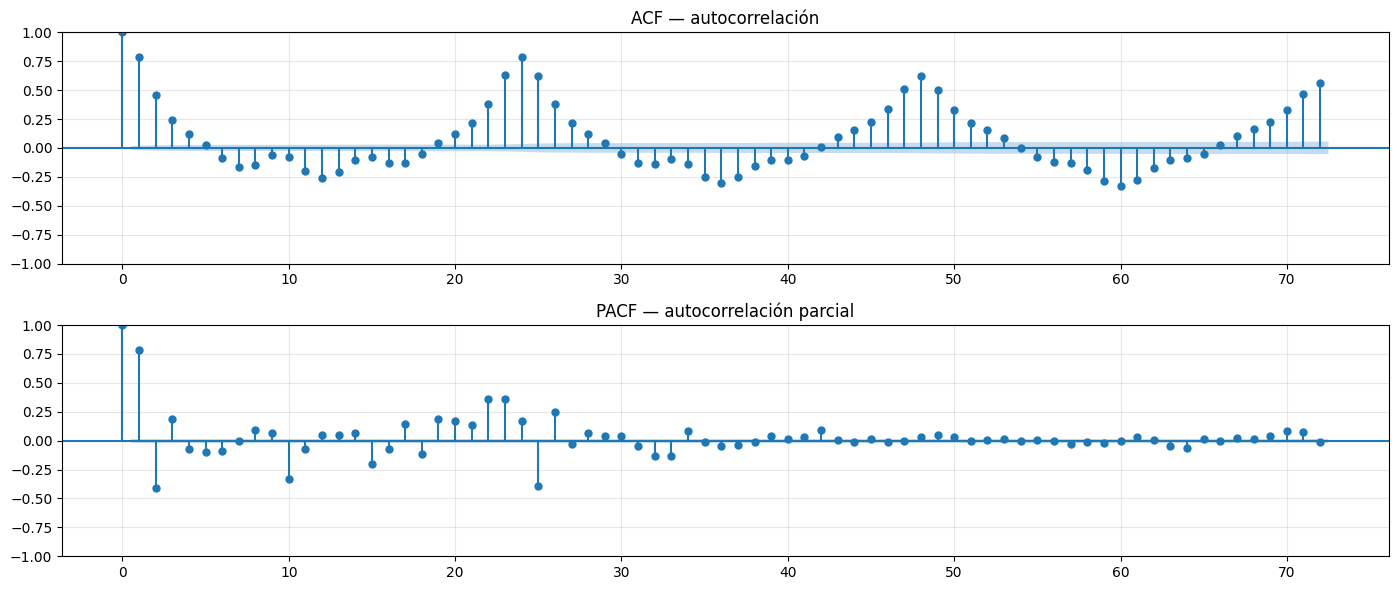

In [26]:
# ACF/PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6))
plot_acf(y, lags=72, ax=ax1)
ax1.set_title('ACF — autocorrelación')
plot_pacf(y, lags=72, ax=ax2, method='ywm')
ax2.set_title('PACF — autocorrelación parcial')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, '03_acf_pacf.png'), dpi=150, bbox_inches='tight')

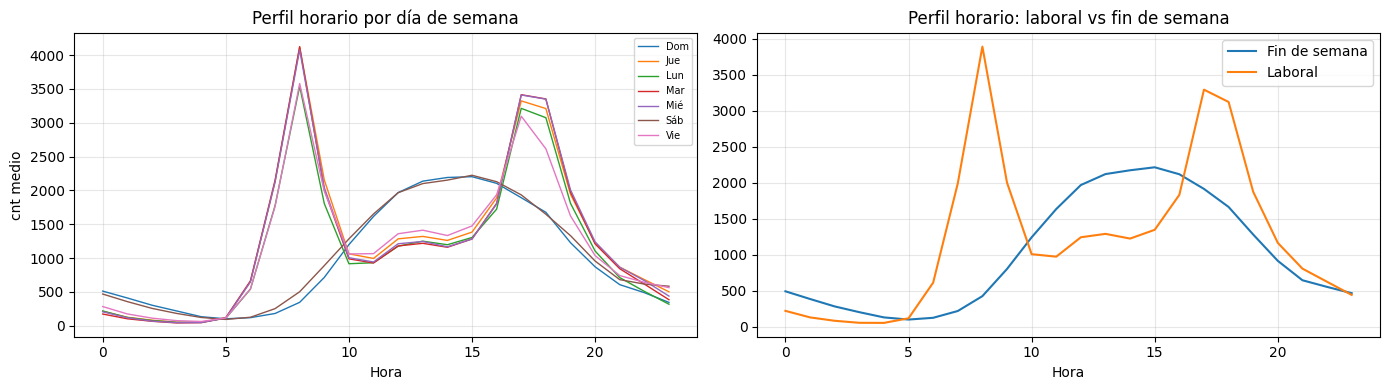

In [27]:
# Patrón horario por tipo de día
train['hour'] = train['timestamp'].dt.hour
train['dayofweek'] = train['timestamp'].dt.dayofweek
train['tipo'] = train['dayofweek'].map({0:'Lun',1:'Mar',2:'Mié',3:'Jue',4:'Vie',5:'Sáb',6:'Dom'})
train['wd'] = np.where(train['dayofweek'] < 5, 'Laboral', 'Fin de semana')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
for label, grp in train.groupby('tipo'):
    ax1.plot(grp.groupby('hour')['cnt'].mean(), label=label, linewidth=1)
ax1.set_title('Perfil horario por día de semana')
ax1.set_xlabel('Hora'); ax1.set_ylabel('cnt medio'); ax1.legend(fontsize=7)

for label, grp in train.groupby('wd'):
    ax2.plot(grp.groupby('hour')['cnt'].mean(), label=label, linewidth=1.5)
ax2.set_title('Perfil horario: laboral vs fin de semana')
ax2.set_xlabel('Hora'); ax2.legend()
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'patron_horario.png'), dpi=150, bbox_inches='tight')

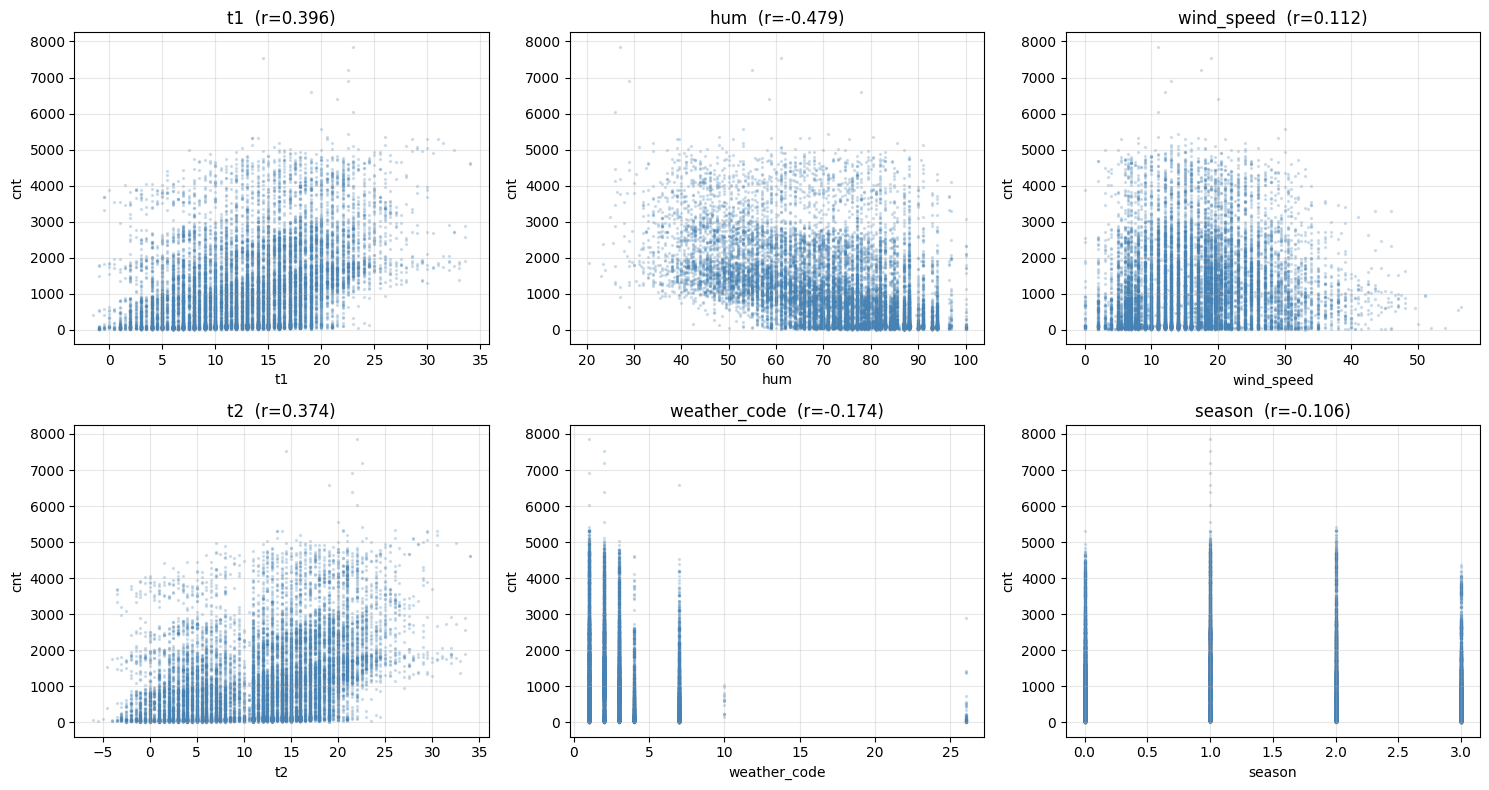

In [28]:
# Relación con variables climáticas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for i, col in enumerate(['t1', 'hum', 'wind_speed', 't2', 'weather_code', 'season']):
    axes[i].scatter(train[col], y, alpha=0.2, s=2, color='steelblue')
    r = np.corrcoef(train[col].fillna(train[col].median()), y)[0, 1]
    axes[i].set_title(f'{col}  (r={r:.3f})')
    axes[i].set_xlabel(col); axes[i].set_ylabel('cnt')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'correlaciones_clima.png'), dpi=150, bbox_inches='tight')

## 4. Ingeniería de características

A partir del timestamp se extraen hora, día, mes, estación y otras variables cíclicas. Se agregan también variables climáticas, interacciones entre hora y tipo de día, y rezagos de temperatura, humedad y viento (1 y 24 horas).

In [29]:
def crear_features_fecha(df):
    ts = pd.to_datetime(df['timestamp'])
    out = pd.DataFrame(index=df.index)
    out['year'] = ts.dt.year; out['month'] = ts.dt.month
    out['day'] = ts.dt.day; out['hour'] = ts.dt.hour
    out['dayofweek'] = ts.dt.dayofweek; out['dayofyear'] = ts.dt.dayofyear
    out['weekofyear'] = ts.dt.isocalendar().week.astype(int)
    out['quarter'] = ts.dt.quarter
    out['time_idx'] = (ts - pd.Timestamp('2015-01-01')).dt.total_seconds() / 3600
    return out


def agregar_ciclicas(df):
    out = pd.DataFrame(index=df.index)
    for var, periodo in [('hour', 24), ('dayofweek', 7), ('month', 12), ('dayofyear', 365.25), ('weekofyear', 52.18)]:
        if var in df:
            out[f'{var}_sin'] = np.sin(2 * np.pi * df[var] / periodo)
            out[f'{var}_cos'] = np.cos(2 * np.pi * df[var] / periodo)
    return out


def agregar_tipo_dia(df):
    out = pd.DataFrame(index=df.index)
    out['is_weekend'] = (df['dayofweek'] >= 5).astype(int) if 'dayofweek' in df else 0
    out['is_holiday'] = df['is_holiday'] if 'is_holiday' in df else 0
    out['working_day'] = ((out['is_weekend'] == 0) & (out['is_holiday'] == 0)).astype(int)
    out['weekend_or_holiday'] = ((out['is_weekend'] == 1) | (out['is_holiday'] == 1)).astype(int)
    if 'hour' in df:
        out['morning_peak'] = df['hour'].between(7, 9).astype(int)
        out['evening_peak'] = df['hour'].between(17, 19).astype(int)
        out['commute_hour'] = ((out['morning_peak'] == 1) | (out['evening_peak'] == 1)).astype(int)
        out['commute_working_day'] = out['commute_hour'] * out['working_day']
        out['night'] = ((df['hour'] <= 5) | (df['hour'] >= 22)).astype(int)
    out['is_rush_hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int) if 'hour' in df else 0
    return out


def agregar_interacciones(df):
    out = pd.DataFrame(index=df.index)
    for c1, c2 in [('hour', 'dayofweek'), ('hour', 'working_day'), ('month', 'hour')]:
        if c1 in df and c2 in df:
            out[f'{c1}__{c2}'] = df[c1].astype(str) + '_' + df[c2].astype(str)
    return out


def agregar_clima(df):
    out = pd.DataFrame(index=df.index)
    for c in ['t1', 't2', 'hum', 'wind_speed', 'weather_code', 'season']:
        if c in df: out[c] = df[c]
    if 't1' in df and 't2' in df:
        out['temp_difference'] = df['t1'] - df['t2']; out['temp_mean'] = (df['t1'] + df['t2']) / 2
    if 't1' in df: out['temp_squared'] = df['t1'] ** 2
    if 'hum' in df: out['humidity_squared'] = df['hum'] ** 2
    if 'wind_speed' in df: out['wind_squared'] = df['wind_speed'] ** 2
    if 't1' in df and 'hum' in df: out['temp_humidity'] = df['t1'] * df['hum']
    if 't1' in df and 'wind_speed' in df: out['temp_wind'] = df['t1'] * df['wind_speed']
    if 'hum' in df and 'wind_speed' in df: out['humidity_wind'] = df['hum'] * df['wind_speed']
    return out


def agregar_clima_lags(df):
    out = pd.DataFrame(index=df.index)
    base = df[['timestamp', 't1', 'hum', 'wind_speed']].copy()
    for var in ['t1', 'hum', 'wind_speed']:
        for lag in [1, 24]:
            ref = base[['timestamp', var]].copy()
            ref['timestamp'] += pd.Timedelta(hours=lag)
            ref = ref.rename(columns={var: f'{var}_lag_{lag}'})
            out[f'{var}_lag_{lag}'] = df['timestamp'].map(ref.set_index('timestamp')[f'{var}_lag_{lag}'])
    if 't1' in df: out['t1_cubic'] = df['t1'] ** 3
    return out


def agregar_hours_since_holiday(df):
    out = pd.DataFrame(index=df.index)
    is_h = df['is_holiday'].fillna(0).astype(int).to_numpy()
    hs = np.zeros(len(df)); hp = np.zeros(len(df), dtype=int); el = None
    for i, hh in enumerate(is_h):
        if hh == 1: el = 0
        elif el is not None: el += 1
        if el is not None: hp[i] = 1; hs[i] = el
    out['has_previous_holiday'] = hp; out['hours_since_holiday'] = hs
    return out


def get_cat_features(df):
    cand = ['hour', 'dayofweek', 'month', 'season', 'weather_code',
            'is_holiday', 'is_weekend', 'working_day', 'weekend_or_holiday',
            'morning_peak', 'evening_peak', 'commute_hour', 'night', 'year', 'quarter']
    return [c for c in cand if c in df.columns] + [c for c in df.columns if '__' in c]


def build_features(df):
    f1 = crear_features_fecha(df); cyc = agregar_ciclicas(f1)
    td = agregar_tipo_dia(pd.concat([f1, df[['is_holiday']]], axis=1))
    cl = agregar_clima(df)
    base_int = pd.concat([f1, td, cl], axis=1); inter = agregar_interacciones(base_int)
    return pd.concat([f1, cyc, td, inter, cl, agregar_clima_lags(df), agregar_hours_since_holiday(df)], axis=1)


In [30]:
# Construir features sobre train + test
train['_source'] = 'train'
test_sorted['_source'] = 'test'
datos = pd.concat([train, test_sorted], ignore_index=True).sort_values('timestamp').reset_index(drop=True)
X_full = build_features(datos)

X = X_full.loc[datos['_source'] == 'train'].reset_index(drop=True)
Xt = X_full.loc[datos['_source'] == 'test'].reset_index(drop=True)
assert X.columns.tolist() == Xt.columns.tolist()
print(f"Features: {X.shape[1]}")

from concurrent.futures import ThreadPoolExecutor, as_completed
import threading, sys, time

N_PARALLEL = 3
THREADS = max(1, os.cpu_count() // N_PARALLEL)
_lock = threading.Lock()
fits_done = 0; total_fits = 0

def progress_msg(name):
    global fits_done
    with _lock:
        fits_done += 1
        pct = 100.0 * fits_done / total_fits
        print(f"  [{pct:3.0f}%] {name}")
        sys.stdout.flush()

cat_features = get_cat_features(X)
cat_idxs = [X.columns.get_loc(c) for c in cat_features if c in X.columns]

def prep_cb(df):
    d = df.copy()
    for idx in cat_idxs:
        col = d.columns[idx]; d[col] = d[col].fillna('__MISSING__').astype(str)
    return d

print(f"Features: {X.shape[1]}  |  Categóricas: {len(cat_idxs)}")

Features: 55
Features: 55  |  Categóricas: 18


## 5. Validación temporal

Se utilizan tres bloques de validación con ventana deslizante. Cada fold entrena con 8000 horas y evalúa sobre las siguientes 2000.

En cada fold, el bloque de entrenamiento precede temporalmente al bloque de validación. Las observaciones no se mezclan dentro de un fold, aunque las ventanas de entrenamiento se superponen entre folds.

El OOF contiene tres bloques de 2000 observaciones cada uno. Se reservan adicionalmente las últimas 1414 observaciones como holdout temporal. El holdout no participa en el ajuste de hiperparámetros ni en la calibración.

In [31]:
N_FOLDS = 3
TRAIN_SIZE = 8000
TEST_SIZE = 2000
STRIDE = 2000
SEEDS = [42, 123, 777]

folds = [(f * STRIDE, f * STRIDE + TRAIN_SIZE, f * STRIDE + TRAIN_SIZE, f * STRIDE + TRAIN_SIZE + TEST_SIZE)
         for f in range(N_FOLDS)]
print("Fold | Train → Valid")
for i, (ts, te, vs, ve) in enumerate(folds):
    print(f"  {i+1}   | [{ts}:{te}] → [{vs}:{ve}]")

Fold | Train → Valid
  1   | [0:8000] → [8000:10000]
  2   | [2000:10000] → [10000:12000]
  3   | [4000:12000] → [12000:14000]


## 6. Entrenamiento con validación cruzada

El modelo base es CatBoostRegressor con PowerTransformer intra-fold. Cada fold transforma el objetivo dentro del bloque de entrenamiento y lo invierte al predecir. Las predicciones OOF se promedian sobre tres semillas.

In [32]:
def run_seed_oof(seed, X, fold_pts, fold_ypt, cat_idxs, prep_cb):
    fp = np.full(len(X), np.nan)
    for f in range(N_FOLDS):
        m = CatBoostRegressor(loss_function='RMSE', iterations=2500, learning_rate=0.025,
                              depth=8, l2_leaf_reg=8, random_strength=0.5,
                              bagging_temperature=0.5, verbose=False, random_seed=seed,
                              thread_count=THREADS)
        ts = f * STRIDE; te2 = ts + TRAIN_SIZE; vs = te2; ve = vs + TEST_SIZE
        m.fit(prep_cb(X.iloc[ts:te2]), fold_ypt[f],
              cat_features=cat_idxs if cat_idxs else None, verbose=False)
        pred = fold_pts[f].inverse_transform(
            m.predict(prep_cb(X.iloc[vs:ve])).reshape(-1, 1)).ravel()
        fp[vs:ve] = pred
        progress_msg(f"OOF s{seed} f{f+1}")
    return fp

fold_pts = {}; fold_ypt = {}
for f in range(N_FOLDS):
    ts = f * STRIDE; te2 = ts + TRAIN_SIZE
    pt = PowerTransformer(method='yeo-johnson')
    fold_ypt[f] = pt.fit_transform(y[ts:te2].reshape(-1, 1)).ravel()
    fold_pts[f] = pt

total_fits = len(SEEDS) * N_FOLDS; fits_done = 0
cb_oof = np.zeros(len(X)); cb_cnt = np.zeros(len(X))
with ThreadPoolExecutor(max_workers=N_PARALLEL) as ex:
    futures = {ex.submit(run_seed_oof, s, X, fold_pts, fold_ypt, cat_idxs, prep_cb): s for s in SEEDS}
    for f in as_completed(futures):
        fp = f.result(); ok = ~np.isnan(fp); cb_oof[ok] += fp[ok]; cb_cnt[ok] += 1

cb_oof = np.divide(cb_oof, cb_cnt, out=np.full_like(cb_oof, np.nan), where=cb_cnt > 0)
valid = ~np.isnan(cb_oof)
pred_oof = np.clip(cb_oof[valid], 0, None); y_oof = y[valid]
seasons_oof = X.loc[valid, 'season'].values.astype(int)
mse_base = mean_squared_error(y_oof, pred_oof)
rmse_base = np.sqrt(mse_base)
print(f"OOF base  — MSE: {mse_base:.0f}  RMSE: {np.sqrt(mse_base):.0f}")

  [ 11%] OOF s123 f1
  [ 22%] OOF s777 f1
  [ 33%] OOF s42 f1
  [ 44%] OOF s42 f2
  [ 56%] OOF s123 f2
  [ 67%] OOF s777 f2
  [ 78%] OOF s42 f3
  [ 89%] OOF s777 f3
  [100%] OOF s123 f3
OOF base  — MSE: 72293  RMSE: 269


### 6.1 Calibración estacional

Se ajusta una regresión lineal por estación para corregir el sesgo sistemático de las predicciones. La evaluación de la calibración se hace con leave-fold-out para evitar fuga.

In [33]:
fold_ids = np.zeros(len(y_oof), dtype=int)
for f in range(N_FOLDS):
    vs = f * STRIDE + TRAIN_SIZE; ve = vs + TEST_SIZE
    fold_ids[(np.arange(len(X))[valid] >= vs) & (np.arange(len(X))[valid] < ve)] = f
pred_oof_cal = np.full(len(y_oof), np.nan)
for f_val in range(N_FOLDS):
    fit_fold = fold_ids != f_val; val_fold = fold_ids == f_val
    for s in np.unique(seasons_oof[val_fold]):
        fit = fit_fold & (seasons_oof == s); val = val_fold & (seasons_oof == s)
        if fit.sum() < 10 or val.sum() < 1: continue
        c = LinearRegression(); c.fit(pred_oof[fit].reshape(-1, 1), y_oof[fit])
        pred_oof_cal[val] = c.predict(pred_oof[val].reshape(-1, 1)).ravel()
pg = np.full(len(y_oof), np.nan)
for f_val in range(N_FOLDS):
    fit = fold_ids != f_val; val = fold_ids == f_val
    c = LinearRegression(); c.fit(pred_oof[fit].reshape(-1, 1), y_oof[fit])
    pg[val] = c.predict(pred_oof[val].reshape(-1, 1)).ravel()
pred_oof_cal = np.clip(np.where(np.isnan(pred_oof_cal), pg, pred_oof_cal), 0, None)
mse_cal = mean_squared_error(y_oof, pred_oof_cal)
rmse_cal = np.sqrt(mse_cal)
print(f"OOF cal   — MSE: {mse_cal:.0f}  RMSE: {np.sqrt(mse_cal):.0f}")

OOF cal   — MSE: 63894  RMSE: 253


In [34]:
cal_frozen = {}
for s in sorted(set(seasons_oof)):
    mask = seasons_oof == s
    if mask.sum() < 10: continue
    cal = LinearRegression(); cal.fit(pred_oof[mask].reshape(-1, 1), y_oof[mask])
    cal_frozen[s] = cal
cal_global = LinearRegression(); cal_global.fit(pred_oof.reshape(-1, 1), y_oof)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


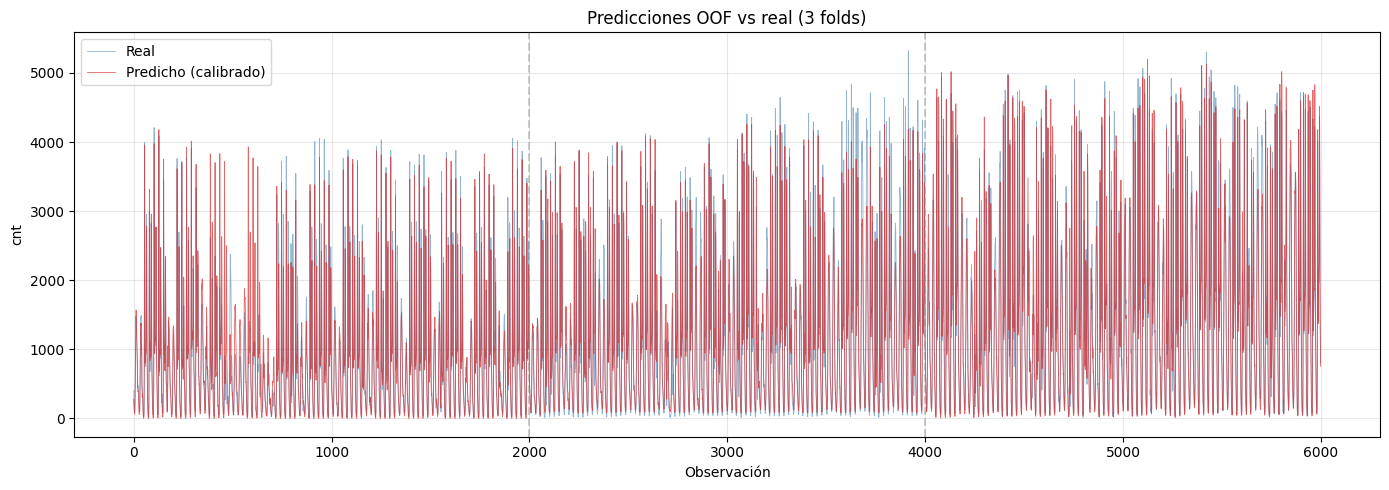

In [35]:
# Gráfica de predicciones OOF
plt.figure(figsize=(14, 5))
idx = np.arange(len(y_oof))
plt.plot(idx, y_oof, label='Real', alpha=0.6, linewidth=0.6, color='steelblue')
plt.plot(idx, pred_oof_cal, label='Predicho (calibrado)', alpha=0.7, linewidth=0.6, color='#d62728')
plt.axvline(x=2000, color='gray', linestyle='--', alpha=0.4)
plt.axvline(x=4000, color='gray', linestyle='--', alpha=0.4)
plt.title('Predicciones OOF vs real (3 folds)')
plt.xlabel('Observación'); plt.ylabel('cnt')
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'predicciones_plot.png'), dpi=150, bbox_inches='tight')

## 7. Resultados — Top 1 (Aplus54_cal)

El mejor modelo utiliza 55 features (A+54), PowerTransformer intra-fold, 3 semillas, y calibración estacional. El OOF cubre 6000h y el holdout las últimas 1414h (sin solapamiento).

In [36]:
# Holdout: entrenar con primeras 14000h, evaluar últimas 1414h (sin solapamiento OOF)
HO_TRAIN = 14000
pt_ho = PowerTransformer(method='yeo-johnson')
y_ho_pt = pt_ho.fit_transform(y[:HO_TRAIN].reshape(-1, 1)).ravel()

pred_ho = np.zeros(len(y) - HO_TRAIN)
for seed in SEEDS:
    m = CatBoostRegressor(loss_function='RMSE', iterations=2500, learning_rate=0.025,
                          depth=8, l2_leaf_reg=8, random_strength=0.5,
                          bagging_temperature=0.5, verbose=False, random_seed=seed,
                          thread_count=THREADS)
    m.fit(prep_cb(X.iloc[:HO_TRAIN]), y_ho_pt,
          cat_features=cat_idxs if cat_idxs else None, verbose=False)
    pred_ho += pt_ho.inverse_transform(
        m.predict(prep_cb(X.iloc[HO_TRAIN:])).reshape(-1, 1)).ravel()
pred_ho /= 3
pred_ho = np.clip(pred_ho, 0, None)

mse_ho_base = mean_squared_error(y[HO_TRAIN:], pred_ho)
rmse_ho_base = np.sqrt(mse_ho_base)
print(f"Holdout base — MSE: {mse_ho_base:.0f}  RMSE: {rmse_ho_base:.0f}")

# Calibración con cal_frozen (aprendidos de OOF, sin fuga)
seasons_ho = X.loc[HO_TRAIN:, 'season'].values.astype(int)
pred_ho_cal = pred_ho.copy()
for s in sorted(set(seasons_ho)):
    cal = cal_frozen.get(s, cal_global)
    pred_ho_cal[seasons_ho == s] = cal.predict(
        pred_ho[seasons_ho == s].reshape(-1, 1)).ravel()
pred_ho_cal = np.clip(pred_ho_cal, 0, None)

mse_ho_cal = mean_squared_error(y[HO_TRAIN:], pred_ho_cal)
rmse_ho_cal = np.sqrt(mse_ho_cal)
print(f"Holdout cal — MSE: {mse_ho_cal:.0f}  RMSE: {rmse_ho_cal:.0f}")

Holdout base — MSE: 62971  RMSE: 251
Holdout cal — MSE: 54055  RMSE: 232


In [37]:
res = pd.DataFrame({
    'Métrica': ['OOF base', 'OOF calibrado', 'Holdout base', 'Holdout calibrado'],
    'MSE': [int(round(mse_base)), int(round(mse_cal)), int(round(mse_ho_base)), int(round(mse_ho_cal))],
    'RMSE': [int(round(rmse_base)), int(round(rmse_cal)), int(round(rmse_ho_base)), int(round(rmse_ho_cal))],
})
res

,Métrica,MSE,RMSE
0,OOF base,72293,269
1,OOF calibrado,63894,253
2,Holdout base,62971,251
3,Holdout calibrado,54055,232


In [38]:
res

,Métrica,MSE,RMSE
0,OOF base,72293,269
1,OOF calibrado,63894,253
2,Holdout base,62971,251
3,Holdout calibrado,54055,232


### 7.1 Experimentos de referencia

Modelos alternativos evaluados con la misma validación temporal:

In [39]:
comparativa = pd.DataFrame({
    'Modelo': [
        'Modelos iniciales (42 features)',
        '  D - XGBoost residual',
        '  A - CatBoost exógeno',
        '  C - LightGBM memoria',
        '  B - CatBoost memoria',
        '  E - ExtraTrees memoria',
        'Optimización V2/V3',
        '  V2 Ensemble 3 modelos   (59f)',
        '  V3 CatBoost + cal       (55f)',
        '  V2 CatBoost 3 seeds     (59f)',
        'Experimentación final',
        '  Aplus54_cal ★           (55f)',
        '  Aplus59_cal             (59f)',
        '  CatBoost_RAW_cal        (59f)',
        '  Blend PT+RAW_cal',
    ],
    'HO MSE': [
        '—', 81676, 86489, 105863, 117349, 126786,
        '—', 63933, 63596, 64738,
        '—', 56889, 59141, 61780, '—',
    ],
})
comparativa

,Modelo,HO MSE
0,Modelos iniciales (42 features),—
1,D - XGBoost residual,81676
2,A - CatBoost exógeno,86489
3,C - LightGBM memoria,105863
4,B - CatBoost memoria,117349
5,E - ExtraTrees memoria,126786
6,Optimización V2/V3,—
7,V2 Ensemble 3 modelos (59f),63933
8,V3 CatBoost + cal (55f),63596
9,V2 CatBoost 3 seeds (59f),64738


## 8. Entrenamiento final — Top 1 Final

Una vez congelada la configuración, el modelo se reentrena con las 15414 observaciones internas completas. En esta etapa se incluye el antiguo holdout porque ya no se utiliza para tomar decisiones.

In [40]:
def run_seed_final(seed, X, Xt, y_all_pt, pt_final, cat_idxs, prep_cb):
    m = CatBoostRegressor(loss_function='RMSE', iterations=2500, learning_rate=0.025,
                          depth=8, l2_leaf_reg=8, random_strength=0.5,
                          bagging_temperature=0.5, verbose=False, random_seed=seed,
                          thread_count=THREADS)
    m.fit(prep_cb(X), y_all_pt, cat_features=cat_idxs if cat_idxs else None, verbose=False)
    pred = pt_final.inverse_transform(m.predict(prep_cb(Xt)).reshape(-1, 1)).ravel()
    progress_msg(f"Final s{seed}")
    return pred

pt_final = PowerTransformer(method='yeo-johnson')
y_all_pt = pt_final.fit_transform(y.reshape(-1, 1)).ravel()

total_fits = len(SEEDS); fits_done = 0
pred_test = np.zeros(len(test_sorted))
with ThreadPoolExecutor(max_workers=N_PARALLEL) as ex:
    futures = {ex.submit(run_seed_final, s, X, Xt, y_all_pt, pt_final, cat_idxs, prep_cb): s for s in SEEDS}
    for f in as_completed(futures):
        pred_test += f.result()
pred_test /= 3; pred_test = np.clip(pred_test, 0, None)

test_seasons = Xt['season'].values.astype(int)
pred_test_cal = pred_test.copy()
for s in sorted(set(test_seasons)):
    cal = cal_frozen.get(s, cal_global)
    pred_test_cal[test_seasons == s] = cal.predict(
        pred_test[test_seasons == s].reshape(-1, 1)).ravel()
pred_test_cal = np.clip(pred_test_cal, 0, None)
fp = pred_test_cal
print(f"Predicción final — media: {fp.mean():.0f}  |  rango: [{fp.min():.0f}, {fp.max():.0f}]")

  [ 33%] Final s777
  [ 67%] Final s123
  [100%] Final s42
Predicción final — media: 933  |  rango: [17, 4917]


Modelo hasta 14000h → test: media=897
Final   (15414h) → test: media=933
Diferencia media (15414h - 14000h): +36.2


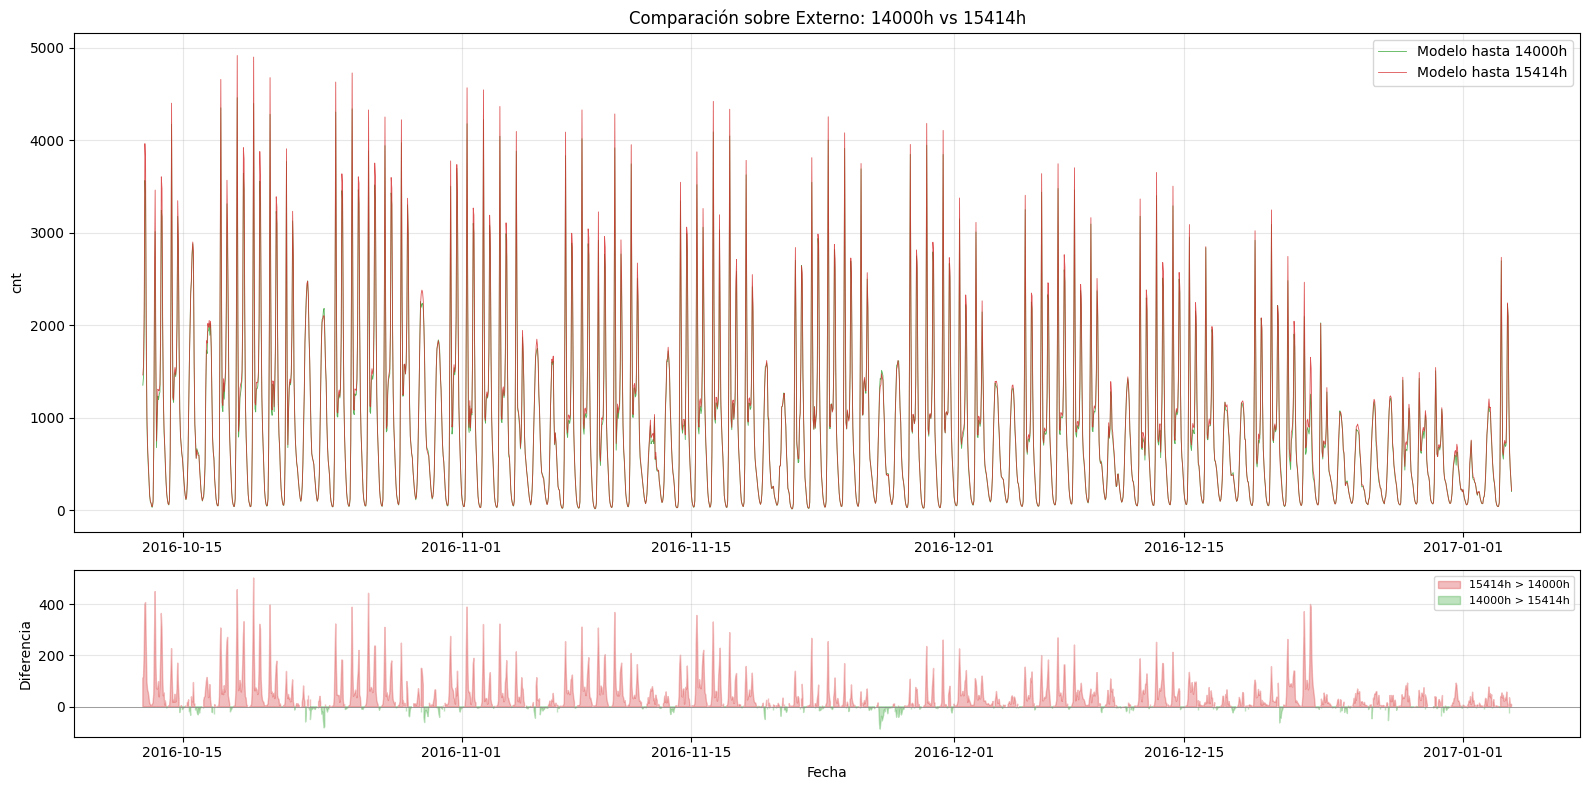

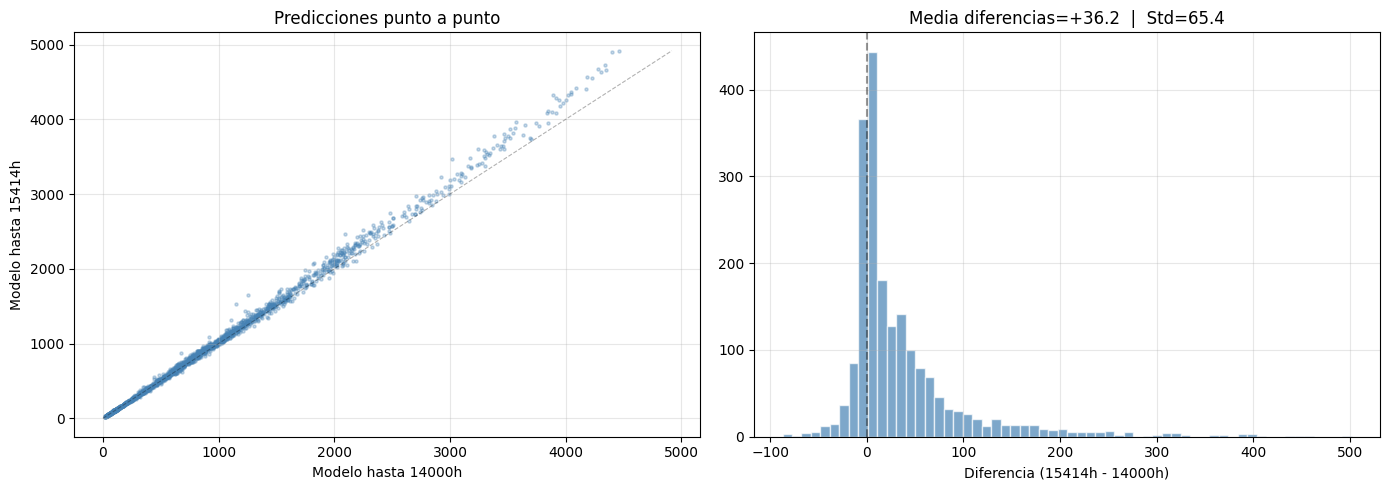

In [41]:
# Comparar modelos entrenados hasta 14000h y 15414h sobre el externo
HO_TRAIN = 14000
pt_ho_test = PowerTransformer(method='yeo-johnson')
y_ho_pt_test = pt_ho_test.fit_transform(y[:HO_TRAIN].reshape(-1, 1)).ravel()

pred_test_ho = np.zeros(len(Xt))
for seed in SEEDS:
    m = CatBoostRegressor(loss_function='RMSE', iterations=2500, learning_rate=0.025,
                          depth=8, l2_leaf_reg=8, random_strength=0.5,
                          bagging_temperature=0.5, verbose=False, random_seed=seed,
                          thread_count=THREADS)
    m.fit(prep_cb(X.iloc[:HO_TRAIN]), y_ho_pt_test,
          cat_features=cat_idxs if cat_idxs else None, verbose=False)
    pred_test_ho += pt_ho_test.inverse_transform(
        m.predict(prep_cb(Xt)).reshape(-1, 1)).ravel()
pred_test_ho /= 3; pred_test_ho = np.clip(pred_test_ho, 0, None)

# Calibración OOF-frozen igual que en el final
test_seasons = Xt['season'].values.astype(int)
pred_test_ho_cal = pred_test_ho.copy()
for s in sorted(set(test_seasons)):
    cal = cal_frozen.get(s, cal_global)
    pred_test_ho_cal[test_seasons == s] = cal.predict(
        pred_test_ho[test_seasons == s].reshape(-1, 1)).ravel()
pred_test_ho_cal = np.clip(pred_test_ho_cal, 0, None)

print(f'Modelo hasta 14000h → test: media={pred_test_ho_cal.mean():.0f}')
print(f'Final   (15414h) → test: media={fp.mean():.0f}')
print(f'Diferencia media (15414h - 14000h): {fp.mean() - pred_test_ho_cal.mean():+.1f}')

# Gráfica 1: series temporales
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [3, 1]})
t = test_sorted['timestamp']
ax1.plot(t, pred_test_ho_cal, label=f'Modelo hasta 14000h', alpha=0.8, linewidth=0.6, color='#2ca02c')
ax1.plot(t, fp, label=f'Modelo hasta 15414h', alpha=0.8, linewidth=0.6, color='#d62728')
ax1.set_title('Comparación sobre Externo: 14000h vs 15414h')
ax1.set_ylabel('cnt'); ax1.legend(); ax1.grid(True, alpha=0.3)

diff = fp - pred_test_ho_cal
ax2.fill_between(t, 0, diff, where=diff >= 0, color='#d62728', alpha=0.3, label='15414h > 14000h')
ax2.fill_between(t, 0, diff, where=diff < 0, color='#2ca02c', alpha=0.3, label='14000h > 15414h')
ax2.axhline(y=0, color='gray', linewidth=0.5)
ax2.set_ylabel('Diferencia'); ax2.set_xlabel('Fecha')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'comparacion_holdout_vs_final_externo.png'), dpi=150, bbox_inches='tight')

# Gráfica 2: scatter + histograma de diferencias
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.scatter(pred_test_ho_cal, fp, alpha=0.3, s=5, color='steelblue')
lims = [0, max(pred_test_ho_cal.max(), fp.max())]
ax1.plot(lims, lims, 'k--', alpha=0.3, linewidth=0.8)
ax1.set_xlabel('Modelo hasta 14000h')
ax1.set_ylabel('Modelo hasta 15414h')
ax1.set_title(f'Predicciones punto a punto')
ax1.grid(True, alpha=0.3)

ax2.hist(diff, bins=60, color='steelblue', edgecolor='white', alpha=0.7)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.4)
ax2.set_xlabel('Diferencia (15414h - 14000h)')
ax2.set_title(f'Media diferencias={diff.mean():+.1f}  |  Std={diff.std():.1f}')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'scatter_holdout_vs_final.png'), dpi=150, bbox_inches='tight')

## 9. Predicciones

Se guarda la submission en `predicciones.csv` con el orden original del archivo de prueba, y un archivo con timestamps para verificación.

In [42]:
sub = pd.DataFrame({'_original_order': test_sorted['_original_order'].to_numpy(), 'cnt': fp})
sub = sub.sort_values('_original_order')[['cnt']].reset_index(drop=True)
assert sub.shape == (2000, 1) and sub.columns.tolist() == ['cnt']
assert sub['cnt'].notna().all() and np.isfinite(sub['cnt']).all() and (sub['cnt'] >= 0).all()
sub.to_csv(os.path.join(OUTPUT_DIR, 'predicciones.csv'), index=False)
sub.to_csv('predicciones.csv', index=False)

ts_df = pd.DataFrame({'timestamp': test_sorted['timestamp'], 'cnt': fp}).reset_index(drop=True)
ts_df.to_csv(os.path.join(OUTPUT_DIR, 'predicciones_timestamps.csv'), index=False)
ts_df.to_csv('predicciones_timestamps.csv', index=False)

meta = {
    'modelo': 'Aplus54_cal_final',
    'entrenado_con': f'todo_train_{len(y)}h',
    'features': int(X.shape[1]), 'seeds': SEEDS,
    'mse_oof_base': round(mse_base, 2),
    'mse_oof_cal': round(mse_cal, 2),
    'pred_test_stats': {
        'mean': round(float(fp.mean()), 1), 'std': round(float(fp.std()), 1),
        'min': round(float(fp.min()), 1), 'p50': round(float(np.median(fp)), 1),
        'p95': round(float(np.percentile(fp, 95)), 1),
        'max': round(float(fp.max()), 1)
    },
}
with open(os.path.join(OUTPUT_DIR, 'metadata.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print(f"predicciones.csv: {len(sub)} filas")

predicciones.csv: 2000 filas


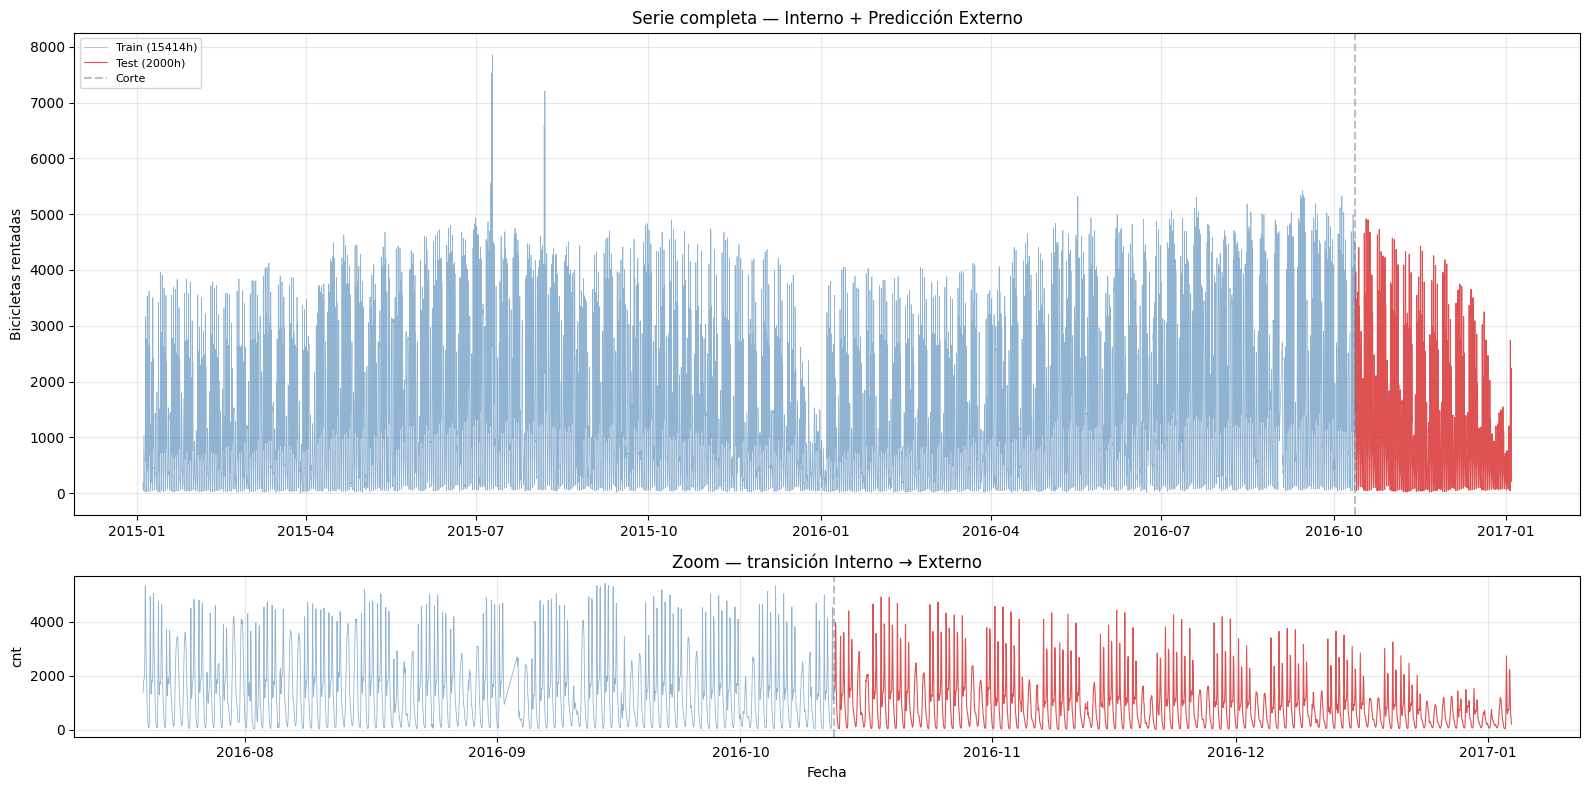

In [43]:
# Gráfica final
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(train['timestamp'], y, label=f'Train ({len(y)}h)', color='steelblue', alpha=0.6, linewidth=0.5)
ax1.plot(ts_df['timestamp'], ts_df['cnt'], label=f'Test ({len(fp)}h)', color='#d62728', alpha=0.8, linewidth=0.8)
ax1.axvline(x=train['timestamp'].iloc[-1], color='gray', linestyle='--', alpha=0.5, label='Corte')
ax1.set_ylabel('Bicicletas rentadas')
ax1.set_title('Serie completa — Interno + Predicción Externo')
ax1.legend(loc='upper left', fontsize=8); ax1.grid(True, alpha=0.3)

zoom = max(0, len(train) - 2000)
ax2.plot(train['timestamp'].iloc[zoom:], y[zoom:], color='steelblue', alpha=0.6, linewidth=0.6)
ax2.plot(ts_df['timestamp'], ts_df['cnt'], color='#d62728', alpha=0.8, linewidth=0.8)
ax2.axvline(x=train['timestamp'].iloc[-1], color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Fecha'); ax2.set_ylabel('cnt')
ax2.set_title('Zoom — transición Interno → Externo')
ax2.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'prediccion_completa.png'), dpi=150, bbox_inches='tight')

## 10. Conclusiones

CatBoost con 55 features (A+54), PowerTransformer intra-fold y calibración estacional obtuvo un MSE OOF de 63,894 (calibrado). Las variables de hora, tipo de día, estación y clima fueron las más relevantes.

El modelo final se entrenó con todas las observaciones disponibles y las predicciones se guardaron respetando el orden original del conjunto de prueba.
